In [2]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"



In [3]:
defaultConfig = {"Budget": 3, "Horizon": 6}
inputConfigs = {
    "(Hal)": {"Theories": [["Hal", "Utility", 0]], "Considerations": [["Hal", "Hal"]]},
    "(Carla)": {"Theories": [["Carla", "Utility", 0]], "Considerations": [["Carla", "Carla"]]},
    "(AU)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Overall", "AU"]]},
    "(Hal, Carla)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Hal", "AU"], ["Carla", "AU"]]},
    "(Hal)^0, (Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Hal", "Hal"]]},
    "(Hal)^0, (Carla)^0, (Hal,Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0], ["AU", "Utility", 0]], "Considerations": [["Carla",["AU", "Carla"]], ["Hal", ["AU", "Hal"]]]},

    "(HalLife)^0, (CarlaLife)^0": {"Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0]],
                    "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"]]
    },
    "(HalLife)^0, (CarlaLife)^0, (HalSmall)^1, (CarlaSmall)^1": {
        "Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0], ["Hal", "Utility", 1], ["Carla", "Utility", 1]],
        "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"], ["Carla", "Carla"], ["Hal", "Hal"]]
    }
}
Config_repetitions=1
Environment_repetitions = 10

In [4]:
configs = []
for name, dat in inputConfigs.items():
    c = deepcopy(defaultConfig)
    c["Name"] = name
    c["Theories"] = dat["Theories"]
    c["Considerations"] = dat["Considerations"]
    c["Budget"] = dat["Budget"] if "Budget" in dat.keys() else c["Budget"]
    c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
    configs.append(c)

In [5]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../../",outFolder="UtilitarianExp")
er.buildEnvironments(configRepetitions=Config_repetitions)
er.runPlanner(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)
er.extractData(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)


Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(Hal)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(Carla)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(AU)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(Hal, Carla)_con0.json

Written LostInsulin MMMDP wi

In [6]:
cols = ["Config_name", 'Hal_Utility', 'Carla_Utility', "Min_non_accept", "Num_of_min_non_accept", "Num_of_sols", "Total_time"]
df = pd.DataFrame(er.data)

df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

df['Carla_Utility'] = df['Carla']
if 'Carla' in df.columns and 'CarlaLife' in df.columns:
    df['Carla_Utility'] = df['Carla'].combine_first(df['CarlaLife'])

df['Hal_Utility'] = df['Hal']
if 'Hal' in df.columns and 'HalLife' in df.columns:
    df['Hal_Utility'] = df['Hal'].combine_first(df['HalLife'])

if 'Overall' in df.columns:
    df['Hal_Utility'] = df['Hal_Utility'].combine_first(df['Overall'])

df['Config_name'] = df['Config_name'].str.replace("HalLife", "HL")
df['Config_name'] = df['Config_name'].str.replace("CarlaLife", "CL")
df['Config_name'] = df['Config_name'].str.replace("HalSmall", "HS")
df['Config_name'] = df['Config_name'].str.replace("CarlaSmall", "CS")
df['Config_name'] = df['Config_name'].str.replace("Hal", "H")
df['Config_name'] = df['Config_name'].str.replace("Carla", "C")

df['Hal_Utility'] = pd.to_numeric(df['Hal_Utility'])
df['Carla_Utility'] = pd.to_numeric(df['Carla_Utility'])
df['Hal_Utility'] = df['Hal_Utility'].round(3)
df['Carla_Utility'] = df['Carla_Utility'].round(3)
df['Min_non_accept'] = df['Min_non_accept'].round(3)

df = df.replace(np.nan, "SKIP")

agg_rules = {
            'Hal_Utility': 'first',
            'Carla_Utility': 'first',
            "Num_of_min_non_accept": 'first',
            "Num_of_sols": 'first',
            "Min_non_accept": 'first',
            'Total_time': 'mean',
        }
        

df_moral = df[cols].groupby('Config_name', sort=False).agg(agg_rules)

SaveDataFrameToTexTemplate(df_moral, f"{er.texTablesFolder}/UtilitarianResults.tex", f"{er.texOutFolder}/Utility_table.tex", row_template_mode=False,timestamp=er.datetimeNow)
df_moral.head(10)

Successfully saved populated LaTeX to /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/tex/Utility_table.tex


,Hal_Utility,Carla_Utility,Num_of_min_non_accept,Num_of_sols,Min_non_accept,Total_time
Config_name,,,,,,
(H),-55.27,SKIP,1,1,0.000,322.6
(C),SKIP,0.0,1,1,0.000,1041.1
(AU),-64.59,SKIP,1,1,0.000,312.2
"(H, C)",-62.776,-1.814,1,16,0.000,6010.4
"(H)^0, (C)^0",-55.27,-24.986,1,16,0.544,5825.4
"(H)^0, (C)^0, (H,C)^0",-62.776,-1.814,1,16,0.646,5864.6
"(HL)^0, (CL)^0",-45.902,-22.114,1,54,0.221,36973.2
"(HL)^0, (CL)^0, (HS)^1, (CS)^1",-55.902,-39.105,1,72,0.221,51606.2


In [7]:
agg_rules = {
    "Expanded_states": "first",
    "Backups": "mean",
    "Iterations": "mean",
    "Total_time": "mean",
}

columns = [
    "Config_name",
    "Expanded_states",
    "Backups",
    "Iterations",
    "Total_time",   
]

df_stat = (
    df[columns]
    .groupby("Config_name", sort=False, as_index=False)
    .agg(agg_rules)
)

SaveDataFrameToTexTemplate(
    df_stat,
    f"{er.texTablesFolder}/PlanResults.tex",
    f"{er.texOutFolder}/Plan_table.tex",
    row_template_mode=True,
    timestamp=er.datetimeNow,
)

df_stat.head(10)

Successfully saved populated LaTeX to /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/tex/Plan_table.tex


,Config_name,Expanded_states,Backups,Iterations,Total_time
0,(H),42,135.0,8.0,322.6
1,(C),82,255.0,8.0,1041.1
2,(AU),38,117.0,8.0,312.2
3,"(H, C)",390,1944.0,11.0,6010.4
4,"(H)^0, (C)^0",390,1944.0,11.0,5825.4
5,"(H)^0, (C)^0, (H,C)^0",390,1944.0,11.0,5864.6
6,"(HL)^0, (CL)^0",618,4409.0,14.0,36973.2
7,"(HL)^0, (CL)^0, (HS)^1, (CS)^1",609,4388.0,14.0,51606.2


## Find the total potential policies for each configuration.

In [8]:
df_ = pd.DataFrame(er.data)[
    [
        "Config_name",
        "Horizon",
        "Total_reachable_policies",
        "Total_states",
    ]
].copy()

value_columns = [
    "Total_reachable_policies",
    "Total_states",
]

# Check whether each Config_name/Horizon pair always has one value
# for both Total_reachable_policies and Total_states.
value_counts = (
    df_
    .groupby(
        ["Config_name", "Horizon"],
        dropna=False,
    )[value_columns]
    .nunique(dropna=False)
)

all_pairs_consistent = value_counts.le(1).all().all()

if not all_pairs_consistent:
    # Keep any Config_name/Horizon pair where at least one measured
    # column has multiple values.
    inconsistent_pairs = value_counts[
        value_counts.gt(1).any(axis=1)
    ]

    print("The following key pairs have multiple values:")
    print(inconsistent_pairs)

    inconsistent_rows = (
        df_
        .merge(
            inconsistent_pairs.index.to_frame(index=False),
            on=["Config_name", "Horizon"],
            how="inner",
        )
        .sort_values(
            ["Config_name", "Horizon"] + value_columns
        )
    )

    print("\nUnderlying inconsistent rows:")
    print(inconsistent_rows)

else:
    result = (
        df_
        .drop_duplicates(
            subset=[
                "Config_name",
                "Horizon",
                *value_columns,
            ]
        )
        .pivot(
            index="Config_name",
            columns="Horizon",
            values=value_columns,
        )
        .sort_index()
        .sort_index(axis=1)
    )

    print(result)

                                                   Total_reachable_policies  \
Horizon                                                                   6   
Config_name                                                                   
(AU)                                                                 507068   
(Carla)                                                              507068   
(Hal)                                                                507068   
(Hal)^0, (Carla)^0                                                   507068   
(Hal)^0, (Carla)^0, (Hal,Carla)^0                                    507068   
(Hal, Carla)                                                         507068   
(HalLife)^0, (CarlaLife)^0                                           507068   
(HalLife)^0, (CarlaLife)^0, (HalSmall)^1, (Carl...                   507068   

                                                   Total_states  
Horizon                                                       6 

## Invetigate the Pareto Front 

/tmp/ipykernel_54564/3872848619.py:334: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Charter.
  fig.tight_layout()
/tmp/ipykernel_54564/3872848619.py:334: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Charter.
  fig.tight_layout()
/tmp/ipykernel_54564/3872848619.py:336: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Charter.
  fig.savefig(
/tmp/ipykernel_54564/3872848619.py:336: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Charter.
  fig.savefig(
/home/psiko/miniconda3/envs/MoralPlanner/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)
/home/psiko/miniconda3/envs/MoralPlanner/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)


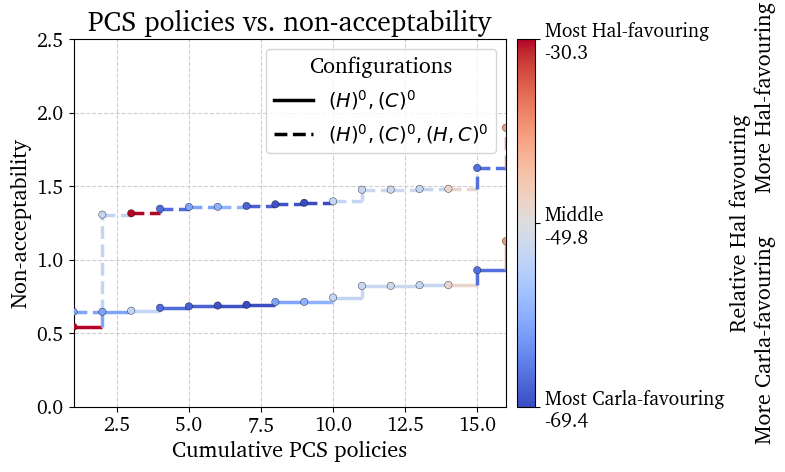

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D


fig, ax = plt.subplots(figsize=(8, 5))

config_names = [
    "(Hal)^0, (Carla)^0",
    "(Hal)^0, (Carla)^0, (Hal,Carla)^0",
]

# Configuration is represented by line style.
config_linestyles = {
    config_names[0]: "solid",
    config_names[1]: "dashed",
}


def numeric_value(solution, *keys):
    """Extract a nested JSON value and convert it to float."""
    value = solution

    for key in keys:
        value = value[key]

    try:
        return float(value)
    except (TypeError, ValueError) as error:
        key_path = " -> ".join(keys)

        raise ValueError(
            f"Expected a numeric value at {key_path}, "
            f"but found {value!r}"
        ) from error


configuration_data = []

for config_name in config_names:
    out_file = er.makePlanOutFileName(
        config_name,
        0,
        0,
    )

    with open(out_file, "r") as file:
        json_data = json.load(file)

    solutions = json_data["Solutions"]

    # Sort complete solution objects so that the expectations remain
    # associated with their corresponding non-acceptability values.
    sorted_solutions = sorted(
        solutions,
        key=lambda solution: numeric_value(
            solution,
            "Acceptability",
        ),
    )

    non_acceptability = np.asarray(
        [
            numeric_value(
                solution,
                "Acceptability",
            )
            for solution in sorted_solutions
        ],
        dtype=float,
    )

    hal_minus_carla = np.asarray(
        [
            numeric_value(
                solution,
                "Expectation",
                "Hal",
            )
            - numeric_value(
                solution,
                "Expectation",
                "Carla",
            )
            for solution in sorted_solutions
        ],
        dtype=float,
    )

    cumulative_policies = np.arange(
        1,
        len(sorted_solutions) + 1,
    )

    configuration_data.append(
        {
            "name": config_name,
            "x": cumulative_policies,
            "y": non_acceptability,
            "difference": hal_minus_carla,
        }
    )


# Combine differences from every configuration so that all plotted policies
# use the same relative colour scale.
all_differences = np.concatenate(
    [
        data["difference"]
        for data in configuration_data
    ]
)

minimum_difference = np.min(all_differences)
maximum_difference = np.max(all_differences)

# Normalise relative to the observed dataset:
#
# minimum difference -> blue
# middle of range    -> white
# maximum difference -> red
#
# This works even when every policy has Hal - Carla < 0.
if np.isclose(minimum_difference, maximum_difference):
    # All policies have effectively the same difference. Expand the range
    # slightly to avoid an invalid normalisation.
    padding = max(
        abs(minimum_difference) * 0.01,
        1e-9,
    )

    minimum_colour_value = minimum_difference - padding
    maximum_colour_value = maximum_difference + padding
    midpoint = minimum_difference
else:
    minimum_colour_value = minimum_difference
    maximum_colour_value = maximum_difference
    midpoint = (
        minimum_difference
        + maximum_difference
    ) / 2.0

normalisation = mcolors.TwoSlopeNorm(
    vmin=minimum_colour_value,
    vcenter=midpoint,
    vmax=maximum_colour_value,
)

# Blue = relatively more favourable to Carla.
# Red = relatively more favourable to Hal.
colour_map = plt.get_cmap("coolwarm")


def make_step_segments(x, y, values):
    """
    Construct a post-style step plot as separately colourable segments.

    Each horizontal section uses the Hal-Carla difference belonging to the
    solution at that non-acceptability level.
    """
    segments = []
    segment_values = []

    if len(x) == 1:
        segments.append(
            [
                (x[0] - 0.15, y[0]),
                (x[0] + 0.15, y[0]),
            ]
        )

        segment_values.append(values[0])

        return (
            np.asarray(segments),
            np.asarray(segment_values),
        )

    for index in range(len(x) - 1):
        # Horizontal part of the post-style step.
        segments.append(
            [
                (x[index], y[index]),
                (x[index + 1], y[index]),
            ]
        )

        segment_values.append(values[index])

        # Vertical transition to the next policy.
        segments.append(
            [
                (x[index + 1], y[index]),
                (x[index + 1], y[index + 1]),
            ]
        )

        # Colour the transition using the policy reached.
        segment_values.append(values[index + 1])

    return (
        np.asarray(segments),
        np.asarray(segment_values),
    )


for data in configuration_data:
    segments, segment_values = make_step_segments(
        data["x"],
        data["y"],
        data["difference"],
    )

    line_collection = LineCollection(
        segments,
        cmap=colour_map,
        norm=normalisation,
        linewidth=2.5,
        linestyles=config_linestyles[data["name"]],
    )

    line_collection.set_array(segment_values)
    ax.add_collection(line_collection)

    # Points make the colour associated with each individual policy clearer.
    ax.scatter(
        data["x"],
        data["y"],
        c=data["difference"],
        cmap=colour_map,
        norm=normalisation,
        s=28,
        edgecolors="black",
        linewidths=0.25,
        zorder=3,
    )


ax.set_title("PCS policies vs. non-acceptability")

ax.set_ylabel("Non-acceptability")
ax.set_xlabel("Cumulative PCS policies")

ax.grid(
    True,
    linestyle="--",
    alpha=0.6,
)

ax.set_ylim(
    bottom=0,
    top=2.5,
)

maximum_policy_count = max(
    data["x"][-1]
    for data in configuration_data
)

ax.set_xlim(
    left=1,
    right=maximum_policy_count,
)


# Create a line-style legend for the two configurations.
configuration_legend_handles = []

for config_name in config_names:
    formatted_name = (
        config_name
        .replace("Hal", "H")
        .replace("Carla", "C")
    )

    configuration_legend_handles.append(
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2.5,
            linestyle=config_linestyles[config_name],
            label=latex_config_name(formatted_name),
        )
    )

ax.legend(
    handles=configuration_legend_handles,
    title="Configurations",
)


# Shared relative colour scale.
scalar_mappable = plt.cm.ScalarMappable(
    norm=normalisation,
    cmap=colour_map,
)

scalar_mappable.set_array([])

colour_bar = fig.colorbar(
    scalar_mappable,
    ax=ax,
    pad=0.02,
)

colour_bar.set_label(
    "Relative Hal favouring\n"
    "More Carla-favouring ←   → More Hal-favouring"
)

# Label the endpoints with the observed numerical differences.
colour_bar.set_ticks(
    [
        minimum_difference,
        midpoint,
        maximum_difference,
    ]
)

colour_bar.set_ticklabels(
    [
        f"Most Carla-favouring\n{minimum_difference:.3g}",
        f"Middle\n{midpoint:.3g}",
        f"Most Hal-favouring\n{maximum_difference:.3g}",
    ]
)


fig.tight_layout()

fig.savefig(
    f"{er.figuresFolder}/Solution_Growth.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [10]:

configs_names = ["(Hal, Carla)", "(Hal)^0, (Carla)^0", "(HalLife)^0, (CarlaLife)^0, (HalSmall)^1, (CarlaSmall)^1"]

data = []
for c in configs_names:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c, 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([c, env_rep, 
                            json_data["Duration_Heuristic"],
                            json_data["Duration_Plan"],
                            json_data["Duration_Sols"],
                            json_data["Duration_MEHR"],
                            json_data["Duration_Total"]])
df = pd.DataFrame(data, columns=["Config_name", "Env_rep", "Heuristic", "Plan", "Solution and Trajectory Extraction", "MEHR", "Total"])
df['Config_name'] = df['Config_name'].str.replace("HalLife", "HL")
df['Config_name'] = df['Config_name'].str.replace("CarlaLife", "CL")
df['Config_name'] = df['Config_name'].str.replace("HalSmall", "HS")
df['Config_name'] = df['Config_name'].str.replace("CarlaSmall", "CS")
df['Config_name'] = df['Config_name'].str.replace("Hal", "H")
df['Config_name'] = df['Config_name'].str.replace("Carla", "C")

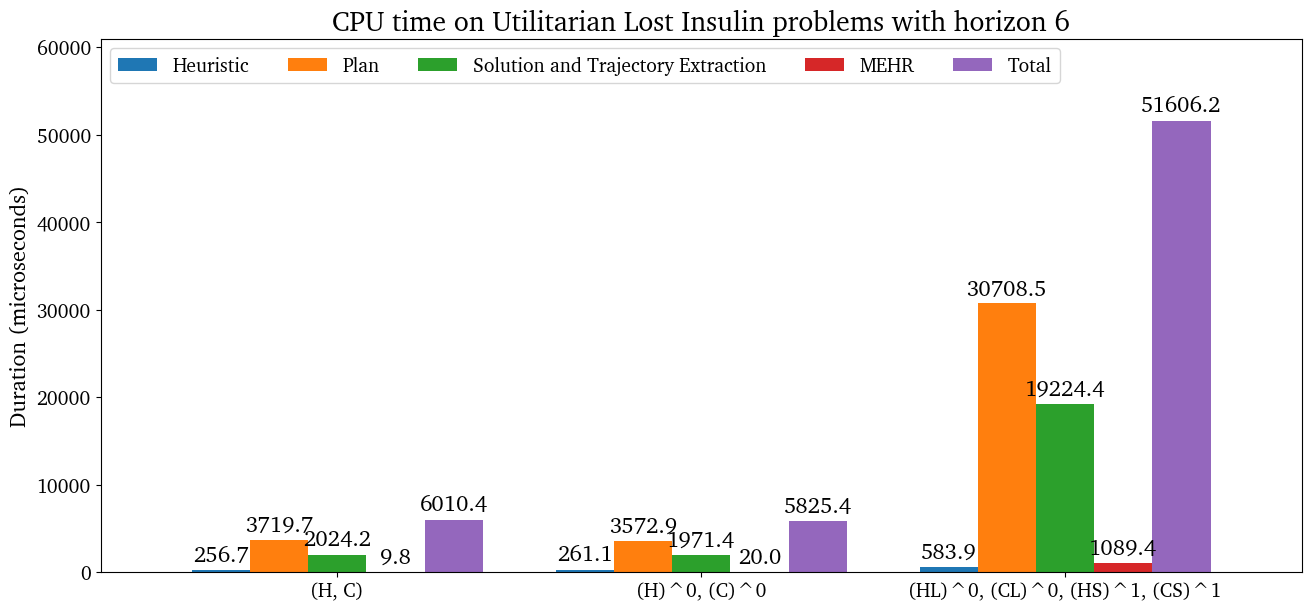

In [11]:

import re
time_categories = ['Heuristic', 'Plan', 'Solution and Trajectory Extraction', 'MEHR', 'Total']

averages = df.groupby('Config_name', sort=False)[time_categories].mean()

fig, ax = plt.subplots(layout='constrained', figsize=(13, 6))

averages.plot.bar(ax=ax, width=0.8, rot=0)

for container in ax.containers:
    formatted_label = re.sub(r"\^(\d)", r"$^{\1}$", str(container))
    ax.bar_label(container, padding=3, fmt='%.1f')
    
ax.set_ylabel('Duration (microseconds)')
ax.set_xlabel('')
ax.set_title('CPU time on Utilitarian Lost Insulin problems with horizon 6')

ax.legend(loc='upper left', ncols=5)
ax.set_ylim(0, df['Total'].max() * 1.05)

plt.savefig(f"{er.figuresFolder}/TimeGraph.png", dpi=300)
plt.show()

In [12]:
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

dep_var = "Total_time"

# Make a copy of the whole dataframe, because you want every Config_name
df_ = df.copy()

# Ensure numeric values
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_["Horizon"] = pd.to_numeric(df_["Horizon"])

fig, ax = plt.subplots(figsize=(10, 7))

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "x", "*"]


for i, config_name in enumerate(configs_names):
    group = df_[df_["Config_name"] == config_name].sort_values("Horizon")
    ax.plot(
        group["Horizon"],
        group[dep_var],
        marker=markers[i  % len(markers)],
        label=latex_config_name(config_name),
        alpha=0.75,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)]
    )

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Total CPU time vs Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel(f"Average total time CPU in microseconds")

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


KeyError: 'Total_time'